In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [ ]:
# 2.1 Collect the Data

In [2]:
df = pd.read_csv("noisy_curvefit_data.csv")

In [3]:
df.shape

(100, 6)

In [4]:
print(df.shape[0], "rows")
print(df.shape[1], "columns")

100 rows
6 columns


In [5]:
df.head()

,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
0,-1.000000,11.624419,8.296963,12.201067,7.811725,3.155566
1,-0.929293,10.377466,9.674440,12.198084,8.275006,7.518855
2,-0.858586,10.585100,9.251983,13.186565,12.926586,9.963630
3,-0.787879,10.913928,7.786344,12.552304,11.832379,9.625801
4,-0.717172,8.640287,8.551869,4.741432,8.790834,6.624113


In [6]:
df.tail()

,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
95,5.717172,-1.411918,0.822231,-2.027132,-1.825106,2.746147
96,5.787879,0.344879,-1.718956,2.747559,-6.803779,-5.137472
97,5.858586,0.307133,0.353528,0.967976,5.461567,-0.905616
98,5.929293,0.048657,0.159961,2.482130,-0.414616,-4.334548
99,6.000000,-0.193438,-2.244792,1.930035,4.992414,-6.872850


In [7]:
df.columns

Index(['x', 'y_noise_1', 'y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5'], dtype='object')

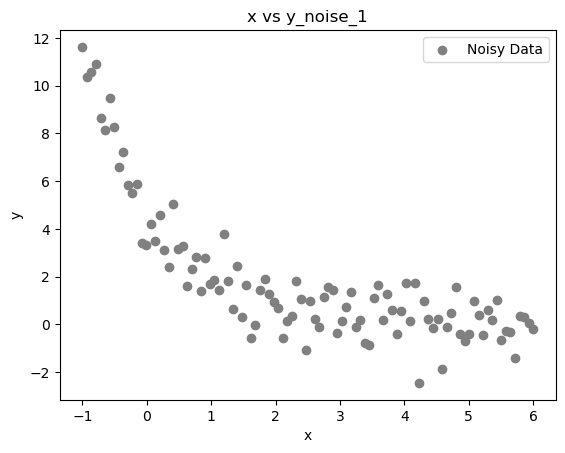

In [8]:
plt.scatter(df["x"], df["y_noise_1"], color="gray", label="Noisy Data")
plt.xlabel("x")
plt.ylabel("y")
plt.title("x vs y_noise_1")
plt.legend()
plt.show()

In [9]:
# 2.2 Fit the Data

In [11]:
def model(x, A, k):
    return A * np.exp(-k * x)

In [12]:
x = df["x"]
y_noise_1 = df["y_noise_1"]

In [13]:
p0 = [1, 1]
popt, pcov = curve_fit(model, x, y_noise_1, p0=p0)

In [14]:
A_fit, k_fit = popt

In [15]:
print(f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)")

Fit: y = 4.71 * e^(-0.92 * x)


In [16]:
residuals = y_noise_1 - model(x, A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced = chi2 / dof

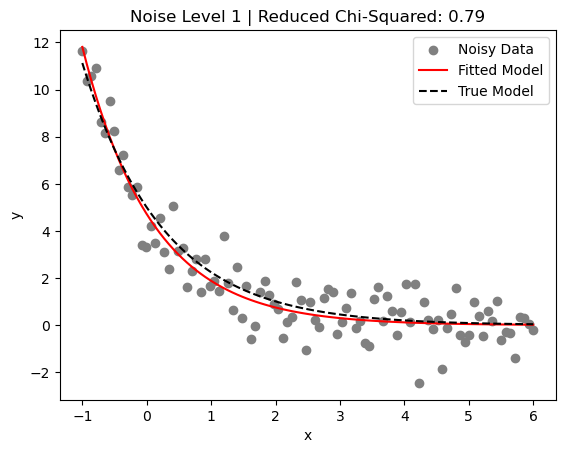

In [17]:
plt.scatter(x, y_noise_1, color="gray", label="Noisy Data")
plt.plot(x, model(x, A_fit, k_fit), color="red", label="Fitted Model")
plt.plot(x, model(x, 5, 0.8), color="black", linestyle="--", label="True Model")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Noise Level 1 | Reduced Chi-Squared: {chi2_reduced:.2f}")
plt.legend()
plt.show()

In [18]:
# 2.3 Compare Different Noise Levels

In [19]:
def fit_model(x, y):
    p0 = [1, 1]
    popt, pcov = curve_fit(model, x, y, p0=p0)
    A_fit, k_fit = popt
    residuals = y - model(x, A_fit, k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced = chi2 / dof
    return popt, chi2_reduced

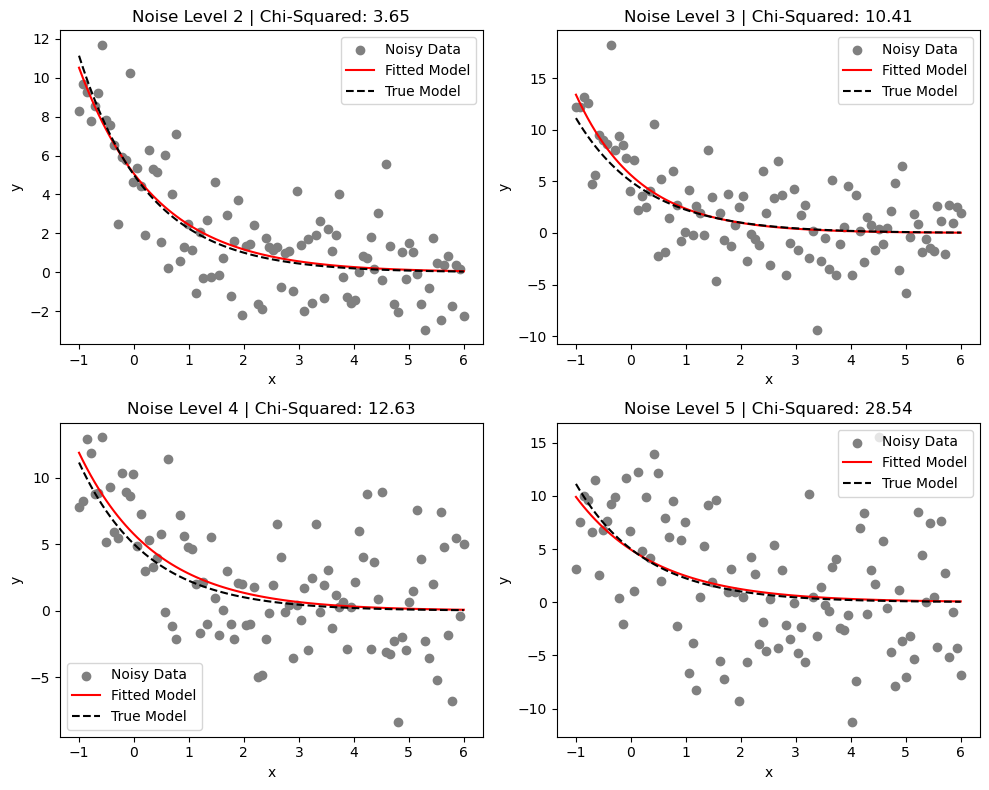

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

noise_levels = [2, 3, 4, 5]

for i, (ax, noise) in enumerate(zip(axes.flatten(), noise_levels)):
    y = df[f"y_noise_{noise}"]
    popt, chi2_reduced = fit_model(x, y)
    A_fit, k_fit = popt
    ax.scatter(x, y, color="gray", label="Noisy Data")
    ax.plot(x, model(x, A_fit, k_fit), color="red", label="Fitted Model")
    ax.plot(x, model(x, 5, 0.8), color="black", linestyle="--", label="True Model")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"Noise Level {noise} | Chi-Squared: {chi2_reduced:.2f}")
    ax.legend()

plt.tight_layout()
plt.show()

In [21]:
# Question 1: The red fitted line moves further away from the black dotted true model line. 
# More noise makes it harder for curve_fit to find the true pattern, so the fitted parameters 
# become less accurate.
# Question 2: The reduced chi-squared increases. More noise means larger residuals, which
# means a worse fit. A value close to 1 is ideal, so the further it gets from 1, the worse 
# the model fits the data.

In [22]:
# 2.4 Save your Results

In [23]:
results = []
for noise in range(1, 6):
    y = df[f"y_noise_{noise}"]
    popt, chi2_reduced = fit_model(x, y)
    A_fit, k_fit = popt
    results.append({"Noise Level": noise, "A_fit": A_fit, "k_fit": k_fit, "Chi2_Reduced": chi2_reduced})

results_df = pd.DataFrame(results)

In [24]:
results_df.shape

(5, 4)

In [25]:
results_df.to_csv("noisy_parameters.csv", index=False)